# Recommendation System for Netflix Prize Dataset using SVD

## By: Ayush Trivedi

In [1]:
from numpy import *
from pandas import *
from matplotlib.pyplot import *

In [2]:
d=read_csv(r"C:\Users\ayush\Downloads\Python Projects\Netflix Project\combined_data_1.txt\combined_data_1.txt")

In [3]:
d.head()

,,1:
1488844,3.0,2005-09-06
822109,5.0,2005-05-13
885013,4.0,2005-10-19
30878,4.0,2005-12-26
823519,3.0,2004-05-03


In [4]:
dataset=read_csv(r'C:\Users\ayush\Downloads\Python Projects\Netflix Project\combined_data_1.txt\combined_data_1.txt',header=None,names=['Cust_Id','Rating'],usecols=[0,1])

In [5]:
dataset['Rating']=dataset['Rating'].astype(float)

In [6]:
dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_Id  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [8]:
dataset.shape

(24058263, 2)

In [9]:
p=dataset.groupby('Rating')['Rating'].agg(['count'])

In [10]:
p

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [11]:
dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [12]:
movie_count=dataset.isnull().sum()[1]
movie_count

4499

In [13]:
cust_count=dataset['Cust_Id'].nunique()-movie_count

In [14]:
cust_count

470758

In [15]:
rating_count=dataset['Cust_Id'].count()-movie_count

In [16]:
rating_count

24053764

Text(0.5, 1.0, 'Total pool : 4499 Movies, 470758 Customers, 24053764 Ratings')

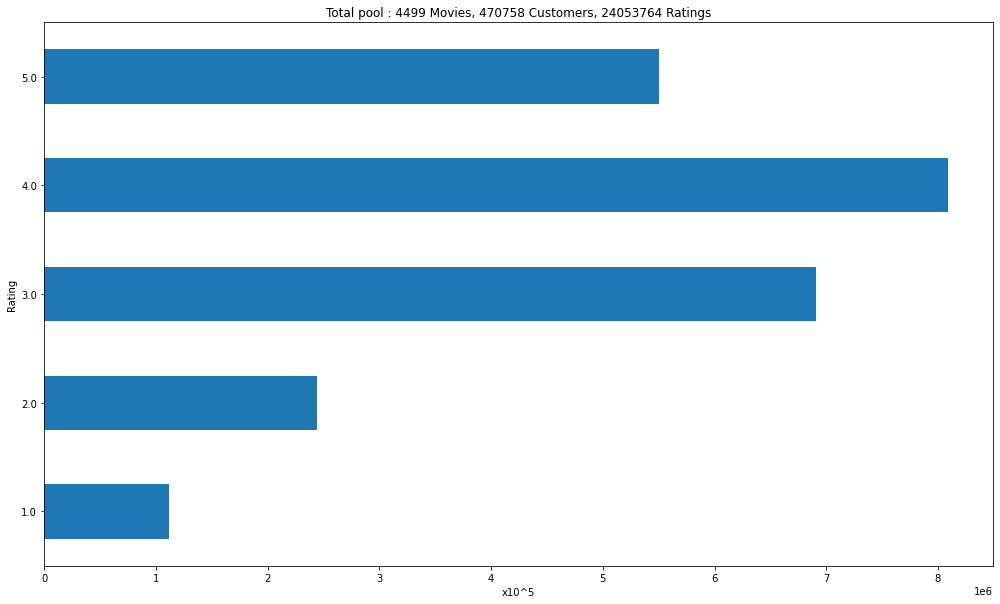

In [17]:
ax=p.plot(kind='barh',figsize=(17,10),legend=False)
xlabel('x10^5')
title(f'Total pool : {movie_count} Movies, {cust_count} Customers, {rating_count} Ratings' )

In [18]:
df_nan=DataFrame(isnull(dataset['Rating']))

In [19]:
df_nan.head()

,Rating
0,True
1,False
2,False
3,False
4,False


In [20]:
df_nan=df_nan[df_nan['Rating']==True]

In [21]:
df_nan

,Rating
0,True
548,True
694,True
2707,True
2850,True
...,...
24046714,True
24047329,True
24056849,True
24057564,True


In [22]:
df_nan=df_nan.reset_index()

In [23]:
df_nan

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True
...,...,...
4494,24046714,True
4495,24047329,True
4496,24056849,True
4497,24057564,True


In [24]:
df_nan['index'][1:]

1            548
2            694
3           2707
4           2850
5           3991
          ...   
4494    24046714
4495    24047329
4496    24056849
4497    24057564
4498    24057834
Name: index, Length: 4498, dtype: int64

In [25]:
df_nan['index'][:-1]

0              0
1            548
2            694
3           2707
4           2850
          ...   
4493    24046583
4494    24046714
4495    24047329
4496    24056849
4497    24057564
Name: index, Length: 4498, dtype: int64

In [26]:
movie_np=[]
movie_id=1
for i,j in zip(df_nan['index'][1:],df_nan['index'][:-1]):
    temp=full((1,i-j-1),movie_id) #full((row,col),data)
    movie_np =append(movie_np,temp)
    movie_id +=1

In [27]:
print(f'length of an array : {len(movie_np)}')

length of an array : 24053336


In [28]:
last_record=full((1,len(dataset)-df_nan.iloc[-1,0]-1),movie_id)
movie_np=append(movie_np,last_record)
print(f'Movie numpy : {movie_np}')
print(f'length of an array : {len(movie_np)}')

Movie numpy : [1.000e+00 1.000e+00 1.000e+00 ... 4.499e+03 4.499e+03 4.499e+03]
length of an array : 24053764


In [29]:
# To append the above created array to the dataset after removing the 'nan' values
dataset=dataset[notnull(dataset['Rating'])]
dataset['Movie_Id']=movie_np.astype(int)
dataset['Cust_Id']=dataset["Cust_Id"].astype(int)
dataset.head(695)


,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
692,1283204,3.0,2
693,1272122,5.0,2
695,1025579,4.0,3
696,712664,5.0,3


In [30]:
f=['count','mean']
#To create a benchmark or to select a movies which are rated often, creating a list of movies which are rated less often
dataset_movie_summary=dataset.groupby('Movie_Id')['Rating'].agg(f)
dataset_movie_summary.index=dataset_movie_summary.index.map(int)
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.7),0) # Here benchmark has been set as 70%
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
print('Movie minimum time of review {}'.format(movie_benchmark))

Movie minimum time of review 1799.0


In [31]:
dataset_movie_summary=dataset.groupby('Movie_Id')['Rating'].agg(f)
dataset_movie_summary.index=dataset_movie_summary.index.map(int)
dataset_movie_summary.head()

,count,mean
Movie_Id,,
1,547,3.749543
2,145,3.558621
3,2012,3.641153
4,142,2.739437
5,1140,3.919298


In [32]:
dataset_movie_summary.index

Int64Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
            ...
            4490, 4491, 4492, 4493, 4494, 4495, 4496, 4497, 4498, 4499],
           dtype='int64', name='Movie_Id', length=4499)

In [33]:
#To create a list of all inactive customers(users who rate less often)
dataset_cust_summary=dataset.groupby('Cust_Id')['Rating'].agg(f)
dataset_cust_summary.index=dataset_cust_summary.index.map(int)
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.7),0)
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
print(f'Customer minimum times of review: {cust_benchmark}')

Customer minimum times of review: 52.0


In [34]:
#Removing all inactive movies and customers from our dataset
dataset=dataset[~dataset['Movie_Id'].isin(drop_movie_list)]
dataset=dataset[~dataset['Cust_Id'].isin(drop_cust_list)]

In [35]:
dataset.shape

(17337458, 3)

In [36]:
dataset.head()

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [37]:
dataset.head()

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [38]:
df_p=pivot_table(dataset,values='Rating',index='Cust_Id',columns='Movie_Id')
print(df_p.shape)

(143458, 1350)


In [39]:
df_p.head()

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
Cust_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
df_title=read_csv(r'C:\Users\ayush\Downloads\Python Projects\Netflix Project\movie_titles.csv',names=['Movie_Id','Year','Name'],encoding='ISO-8859-1')
df_title.set_index('Movie_Id',inplace=True)

In [41]:
df_title.head()

,Year,Name
Movie_Id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW


In [42]:
df_title['Name']

Movie_Id
1                                          Dinosaur Planet
2                               Isle of Man TT 2004 Review
3                                                Character
4                             Paula Abdul's Get Up & Dance
5                                 The Rise and Fall of ECW
                               ...                        
17766    Where the Wild Things Are and Other Maurice Se...
17767                    Fidel Castro: American Experience
17768                                                Epoch
17769                                          The Company
17770                                         Alien Hunter
Name: Name, Length: 17770, dtype: object

In [43]:
import math
from surprise import Reader,SVD,Dataset
from surprise.model_selection import cross_validate

In [44]:
reader=Reader()

In [45]:
data=Dataset.load_from_df(dataset[['Cust_Id','Movie_Id','Rating']][:100000],reader)#Get just top 10K rows for faster run time
svd=SVD()
cross_validate(svd,data,measures=['RMSE','MAE'],cv=3,verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9987  0.9950  1.0002  0.9979  0.0022  
MAE (testset)     0.8052  0.8061  0.8081  0.8065  0.0012  
Fit time          6.61    5.72    5.69    6.01    0.43    
Test time         0.29    0.31    0.28    0.29    0.02    


{'test_rmse': array([0.99870761, 0.99498238, 1.00015509]),
 'test_mae': array([0.80524838, 0.80612441, 0.80806153]),
 'fit_time': (6.614588737487793, 5.7188944816589355, 5.694711685180664),
 'test_time': (0.29122138023376465, 0.3131535053253174, 0.2762606143951416)}

In [46]:
dataset.head()

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [47]:
#To find all the movies rated as 5 stars by user with user id 712664
dataset_712664=dataset[(dataset["Cust_Id"]==712664) & (dataset['Rating']==5)]
dataset_712664=dataset_712664.set_index('Movie_Id')
dataset_712664=dataset_712664.join(df_title)['Name']
dataset_712664.head(10)

Movie_Id
3                              Character
79                           The Killing
175                       Reservoir Dogs
199                      The Deer Hunter
241                   North by Northwest
256    Ghost Dog: The Way of the Samurai
348        The Last Temptation of Christ
357                House of Sand and Fog
416                             Elephant
442                  Mississippi Burning
Name: Name, dtype: object

In [48]:
user_712664=df_title.copy()#Create a shallow copy for the datasets
user_712664=user_712664.reset_index()
user_712664=user_712664[~user_712664['Movie_Id'].isin(drop_movie_list)]#To remove all the movies rated less often
data=Dataset.load_from_df(dataset[['Cust_Id','Movie_Id','Rating']],reader)#Getting full dataset
trainset=data.build_full_trainset()#create a training set for svd
svd.fit(trainset)
user_712664['Estimate_Score']=user_712664['Movie_Id'].apply(lambda x: svd.predict(712664,x).est)# Predicting the reatings/Estimate score for this user
user_712664=user_712664.drop('Movie_Id',axis=1)#Droppinf extra columns from the user_712664 dataframe
user_712664=user_712664.sort_values('Estimate_Score',ascending=False)#Sorting the movies in descending order on basis of estimation score
print(user_712664.head(10))#Printing top 10 recommendations


        Year                                      Name  Estimate_Score
174   1992.0                            Reservoir Dogs        5.000000
32    2000.0            Aqua Teen Hunger Force: Vol. 1        5.000000
1276  1988.0                       Red Dwarf: Series 3        5.000000
2101  1994.0                    The Simpsons: Season 6        5.000000
4053  1990.0  House of Cards Trilogy I: House of Cards        5.000000
1847  1956.0  Samurai Trilogy 3: Duel at Ganryu Island        5.000000
721   2003.0                        The Wire: Season 1        5.000000
1691  1989.0                             Lonesome Dove        5.000000
871   1954.0                             Seven Samurai        5.000000
2018  2004.0                          Samurai Champloo        4.992571
